# Block E: Baseline Model – Random Forest

This notebook trains an interpretable **Random Forest** baseline classifier to predict **Normal vs Pathological** outcomes from **window-level CTG features** (Block D).

## Key points
- Uses **grouped split by `record_id`** to prevent leakage (overlapping windows from same recording must not appear in both train and test).
- Evaluates: **ROC-AUC**, **confusion matrix**, **sensitivity/recall**, **specificity**, **precision**, **F1**
- Saves: trained model + evaluation artifacts to `outputs/models/`


In [1]:
import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    confusion_matrix, classification_report,
    precision_score, recall_score, f1_score, accuracy_score
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Repro
RANDOM_STATE = 42

# Paths (notebook-safe: notebooks/ -> project root)
PROJECT_ROOT = Path.cwd().resolve().parent  # <- CTG/
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
MODELS_DIR = OUTPUTS_DIR / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

FEATURES_CSV = OUTPUTS_DIR / "feature_matrix.csv"
REPORT_JSON = MODELS_DIR / "rf_blockE_report.json"
ROC_PNG = MODELS_DIR / "rf_blockE_roc.png"
CM_PNG = MODELS_DIR / "rf_blockE_confusion_matrix.png"
MODEL_PATH = MODELS_DIR / "rf_blockE_model.joblib"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("FEATURES_CSV exists?", FEATURES_CSV.exists(), FEATURES_CSV)
print("MODELS_DIR:", MODELS_DIR)



PROJECT_ROOT: /home/naem_haq/projects/CTG
FEATURES_CSV exists? True /home/naem_haq/projects/CTG/outputs/feature_matrix.csv
MODELS_DIR: /home/naem_haq/projects/CTG/outputs/models


In [2]:
df = pd.read_csv(FEATURES_CSV)

print("Loaded:", df.shape)
print(df[["record_id", "window_idx", "outcome_label"]].head())
print("\nLabel counts:\n", df["outcome_label"].value_counts(dropna=False))


Loaded: (29989, 49)
   record_id  window_idx outcome_label
0       1001           0  Pathological
1       1001           1  Pathological
2       1001           2  Pathological
3       1001           3  Pathological
4       1001           4  Pathological

Label counts:
 outcome_label
Normal          24358
Pathological     5631
Name: count, dtype: int64


In [3]:
# Keep only Normal/Pathological for RF (drop unknown/blank if any)
df = df[df["outcome_label"].isin(["Normal", "Pathological"])].copy()

# Target: Pathological = 1, Normal = 0
y = (df["outcome_label"] == "Pathological").astype(int)

# Grouping to prevent leakage
groups = df["record_id"].astype(str)

# Columns to exclude from features
META_COLS = {
    "record_id", "window_idx", "start_sample", "end_sample",
    "start_min", "end_min", "fs", "outcome_label"
}

feature_cols = [c for c in df.columns if c not in META_COLS]

X = df[feature_cols].copy()

print("X shape:", X.shape)
print("y positives:", int(y.sum()), "/", len(y))
print("Num features:", len(feature_cols))
print("\nExample features:", feature_cols[:10])


X shape: (29989, 41)
y positives: 5631 / 29989
Num features: 41

Example features: ['fhr_remaining_nan_pct', 'fhr_valid_pct_post', 'fhr_baseline_median', 'fhr_mean', 'fhr_median', 'fhr_trimmed_mean_10', 'fhr_std', 'fhr_mad', 'fhr_iqr', 'fhr_mean_abs_diff']


In [4]:
num_inf = np.isinf(X.select_dtypes(include=[np.number]).to_numpy()).sum()
print("INF count:", int(num_inf))

nan_rate = X.isna().mean().sort_values(ascending=False)
print("\nTop NaN-rate columns:")
print(nan_rate.head(15))

# Ensure all features are numeric (convert if needed)
for c in feature_cols:
    X[c] = pd.to_numeric(X[c], errors="coerce")

print("\nAfter coercion: total NaNs =", int(X.isna().sum().sum()))


INF count: 0

Top NaN-rate columns:
fhr_remaining_nan_pct    0.0
fhr_valid_pct_post       0.0
fhr_baseline_median      0.0
fhr_mean                 0.0
fhr_median               0.0
fhr_trimmed_mean_10      0.0
fhr_std                  0.0
fhr_mad                  0.0
fhr_iqr                  0.0
fhr_mean_abs_diff        0.0
fhr_std_1min_means       0.0
accel_count              0.0
accel_total_dur_sec      0.0
accel_mean_dur_sec       0.0
accel_max_dur_sec        0.0
dtype: float64

After coercion: total NaNs = 0


In [5]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
y_train, y_test = y.iloc[train_idx].copy(), y.iloc[test_idx].copy()
groups_train, groups_test = groups.iloc[train_idx], groups.iloc[test_idx]

print("Train windows:", X_train.shape[0], " Test windows:", X_test.shape[0])
print("Train records:", groups_train.nunique(), " Test records:", groups_test.nunique())

# Verify no overlap in record_id
overlap = set(groups_train.unique()).intersection(set(groups_test.unique()))
print("Record overlap:", len(overlap))
assert len(overlap) == 0, "Leakage: same record_id in train and test!"


Train windows: 21153  Test windows: 8836
Train records: 385  Test records: 165
Record overlap: 0


In [6]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=RANDOM_STATE,
    class_weight="balanced",
    n_jobs=-1
)

pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),  # robust & simple
    ("rf", rf)
])

pipeline


,steps,"[('imputer', ...), ('rf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,n_estimators,200


In [7]:
pipeline.fit(X_train, y_train)
print("Training complete.")


Training complete.


In [8]:
# Probabilities for ROC-AUC
y_proba = pipeline.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)

auc = roc_auc_score(y_test, y_proba)

cm = confusion_matrix(y_test, y_pred)  # [[TN, FP],[FN, TP]]
tn, fp, fn, tp = cm.ravel()

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
sensitivity = recall_score(y_test, y_pred, zero_division=0)  # recall for positive class
specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
f1 = f1_score(y_test, y_pred, zero_division=0)

print("ROC-AUC:", auc)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Sensitivity (Recall):", sensitivity)
print("Specificity:", specificity)
print("F1:", f1)

print("\nConfusion matrix [[TN, FP],[FN, TP]]:\n", cm)
print("\nClassification report:\n", classification_report(y_test, y_pred, target_names=["Normal", "Pathological"]))


ROC-AUC: 0.5536176160892955
Accuracy: 0.7217066545948393
Precision: 0.28013698630136985
Sensitivity (Recall): 0.22509631260319207
Specificity: 0.8502635703091609
F1: 0.24961855355508086

Confusion matrix [[TN, FP],[FN, TP]]:
 [[5968 1051]
 [1408  409]]

Classification report:
               precision    recall  f1-score   support

      Normal       0.81      0.85      0.83      7019
Pathological       0.28      0.23      0.25      1817

    accuracy                           0.72      8836
   macro avg       0.54      0.54      0.54      8836
weighted avg       0.70      0.72      0.71      8836



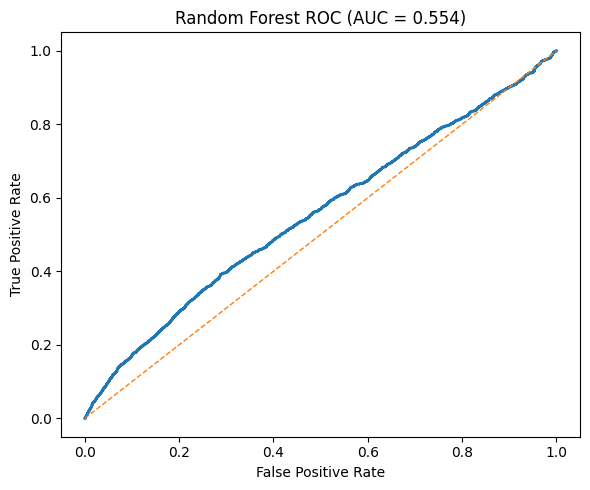

Saved: /home/naem_haq/projects/CTG/outputs/models/rf_blockE_roc.png


In [9]:
fpr, tpr, thr = roc_curve(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, linewidth=2)
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"Random Forest ROC (AUC = {auc:.3f})")
plt.tight_layout()
plt.savefig(ROC_PNG, dpi=200)
plt.show()

print("Saved:", ROC_PNG)


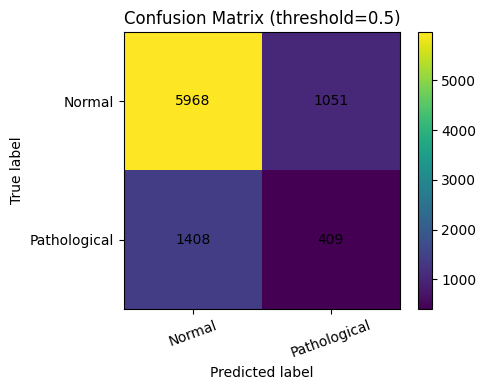

Saved: /home/naem_haq/projects/CTG/outputs/models/rf_blockE_confusion_matrix.png


In [10]:
plt.figure(figsize=(5, 4))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix (threshold=0.5)")
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ["Normal", "Pathological"], rotation=20)
plt.yticks(tick_marks, ["Normal", "Pathological"])

# annotate
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.savefig(CM_PNG, dpi=200)
plt.show()

print("Saved:", CM_PNG)


                    feature  importance
7                   fhr_mad    0.048633
3                  fhr_mean    0.045608
6                   fhr_std    0.044982
5       fhr_trimmed_mean_10    0.043956
2       fhr_baseline_median    0.042947
8                   fhr_iqr    0.041575
4                fhr_median    0.040960
30                  uc_mean    0.038580
33                 uc_range    0.037740
27     fhr_spectral_entropy    0.036300
40                   uc_auc    0.036047
32                   uc_max    0.033292
28         fhr_perm_entropy    0.031190
31                   uc_std    0.029938
10       fhr_std_1min_means    0.028273
26   fhr_bandpower_0p15_0p5    0.028125
9         fhr_mean_abs_diff    0.028016
25  fhr_bandpower_0p03_0p15    0.027978
36              uc_peak_max    0.027884
21        decel_max_dur_sec    0.027085


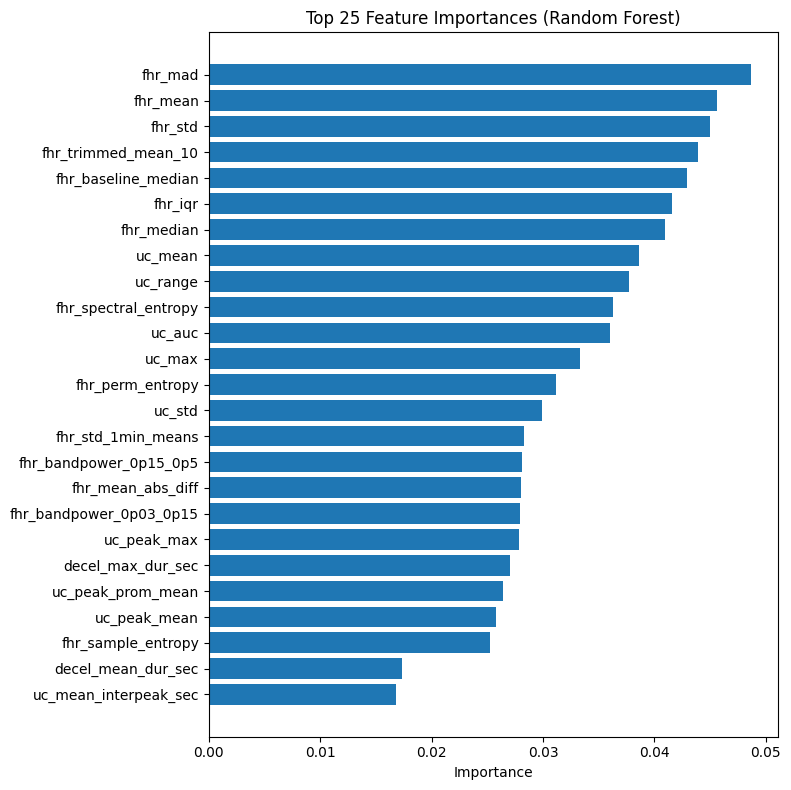

In [11]:
rf_model = pipeline.named_steps["rf"]
importances = rf_model.feature_importances_

fi = pd.DataFrame({
    "feature": feature_cols,
    "importance": importances
}).sort_values("importance", ascending=False)

print(fi.head(20))

top_k = 25
fi_top = fi.head(top_k).iloc[::-1]  # reverse for horizontal bar chart

plt.figure(figsize=(8, 8))
plt.barh(fi_top["feature"], fi_top["importance"])
plt.xlabel("Importance")
plt.title(f"Top {top_k} Feature Importances (Random Forest)")
plt.tight_layout()
plt.show()


In [12]:
# Save model
joblib.dump(pipeline, MODEL_PATH)
print("Saved model:", MODEL_PATH)

# Save report
report = {
    "random_state": RANDOM_STATE,
    "n_train_windows": int(len(X_train)),
    "n_test_windows": int(len(X_test)),
    "n_train_records": int(groups_train.nunique()),
    "n_test_records": int(groups_test.nunique()),
    "feature_count": int(len(feature_cols)),
    "roc_auc": float(auc),
    "accuracy": float(accuracy),
    "precision": float(precision),
    "sensitivity_recall": float(sensitivity),
    "specificity": float(specificity),
    "f1": float(f1),
    "confusion_matrix": {
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp)
    },
    "top_features": fi.head(30).to_dict(orient="records"),
}

with open(REPORT_JSON, "w") as f:
    json.dump(report, f, indent=2)

print("Saved report:", REPORT_JSON)


Saved model: /home/naem_haq/projects/CTG/outputs/models/rf_blockE_model.joblib
Saved report: /home/naem_haq/projects/CTG/outputs/models/rf_blockE_report.json


In [13]:
# Sweep thresholds and show a few operating points
thresholds = np.linspace(0.05, 0.95, 19)
rows = []

for t in thresholds:
    yp = (y_proba >= t).astype(int)
    cm_t = confusion_matrix(y_test, yp)
    tn, fp, fn, tp = cm_t.ravel()

    sens = tp / (tp + fn) if (tp + fn) else np.nan
    spec = tn / (tn + fp) if (tn + fp) else np.nan
    prec = tp / (tp + fp) if (tp + fp) else np.nan

    rows.append({"threshold": float(t), "sensitivity": sens, "specificity": spec, "precision": prec})

thr_df = pd.DataFrame(rows)
print(thr_df)

# Example: choose threshold giving sensitivity >= 0.85 (if possible)
cand = thr_df[thr_df["sensitivity"] >= 0.85].sort_values("specificity", ascending=False)
if len(cand):
    print("\nBest (sens>=0.85) by specificity:\n", cand.head(5))
else:
    print("\nNo threshold achieved sensitivity >= 0.85 on this split.")


    threshold  sensitivity  specificity  precision
0        0.05     0.995597     0.005984   0.205896
1        0.10     0.976885     0.020658   0.205226
2        0.15     0.957622     0.042029   0.205577
3        0.20     0.931205     0.065394   0.205041
4        0.25     0.900385     0.100727   0.205838
5        0.30     0.843148     0.167403   0.207701
6        0.35     0.730875     0.313008   0.215935
7        0.40     0.528894     0.549081   0.232913
8        0.45     0.345074     0.752386   0.265116
9        0.50     0.225096     0.850264   0.280137
10       0.55     0.161255     0.907109   0.310053
11       0.60     0.117777     0.940305   0.338073
12       0.65     0.074849     0.962815   0.342569
13       0.70     0.045129     0.980054   0.369369
14       0.75     0.020914     0.991024   0.376238
15       0.80     0.007155     0.996866   0.371429
16       0.85     0.000000     0.999573   0.000000
17       0.90     0.000000     1.000000        NaN
18       0.95     0.000000     